### Peek at the file structure

In [14]:
%pip install numpy
%pip install pandas
%pip install ultralytics
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [9]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

images = []
labels = []
configs = []
base_path = './data'

for dirname, _, filenames in os.walk(base_path):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        
        if filename.endswith(('.jpg', '.png', '.jpeg')):
            images.append(full_path)
        elif filename.endswith('.txt'):
            labels.append(full_path)
        elif filename.endswith(('.yaml', '.yml')):
            configs.append(full_path)

# Show first 10 of each
print("Images:")
print(images[:10])

print("\nLabels:")
print(labels[:10])

print("\nConfig files:")
print(configs[:10])

Images:
['./data\\images\\test\\PID_xray_00024.jpg', './data\\images\\test\\PID_xray_00035.jpg', './data\\images\\test\\PID_xray_00039.jpg', './data\\images\\test\\PID_xray_00047.jpg', './data\\images\\test\\PID_xray_00061.jpg', './data\\images\\test\\PID_xray_00062.jpg', './data\\images\\test\\PID_xray_00062_aug3287.jpg', './data\\images\\test\\PID_xray_00065.jpg', './data\\images\\test\\PID_xray_00072.jpg', './data\\images\\test\\PID_xray_00083_aug4387.jpg']

Labels:
['./data\\labels\\test\\PID_xray_00188_aug5691.txt', './data\\labels\\test\\PID_xray_00211.txt', './data\\labels\\test\\PID_xray_00212.txt', './data\\labels\\test\\PID_xray_00221.txt', './data\\labels\\test\\PID_xray_00227_aug4569.txt', './data\\labels\\test\\PID_xray_00231.txt', './data\\labels\\test\\PID_xray_00234.txt', './data\\labels\\test\\PID_xray_00242.txt', './data\\labels\\test\\PID_xray_00251.txt', './data\\labels\\test\\PID_xray_00252.txt']

Config files:
['./data\\data.yaml', './data\\SPXray.yaml']


#### Ultralytics is needed for YOLO

In [15]:
import os
import random
import yaml

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

#### Let's visualize/peek at some images

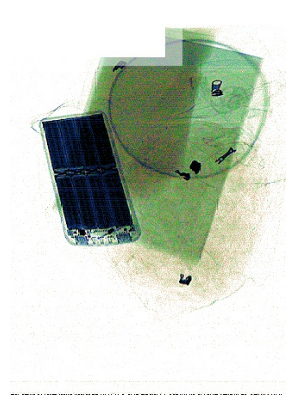

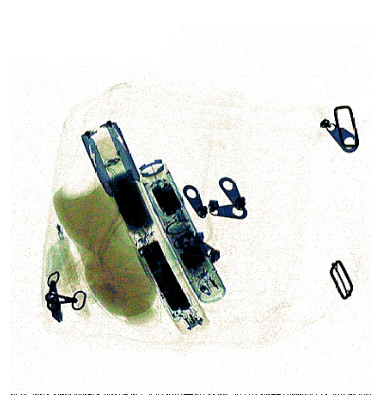

In [37]:
images = "./data/images/train"
N_SAMPLES = 2
for _ in range(N_SAMPLES):
    random_sample = random.choice(os.listdir(images))

    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(os.path.join(images, random_sample)))
    # The x and y axis mean nothing to us
    plt.axis('off')

    plt.show()

#### Let's add the bounding boxes

./data/labels/train\PID_xray_00449.txt


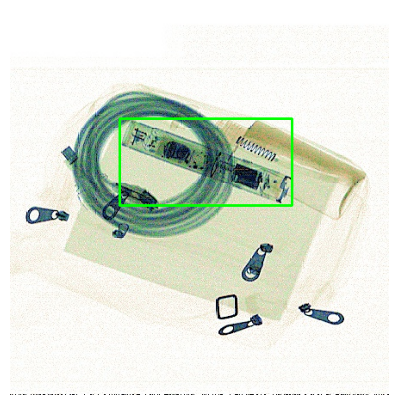

./data/labels/train\PID_xray_easy04329.txt


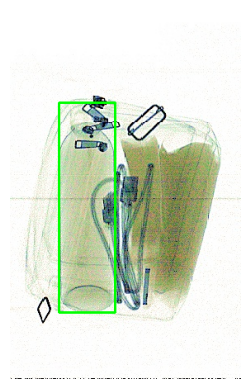

./data/labels/train\PID_xray_easy01803.txt


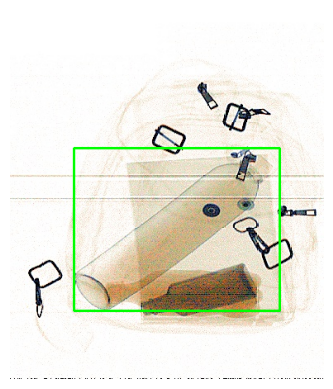

./data/labels/train\SIX_P02962.txt


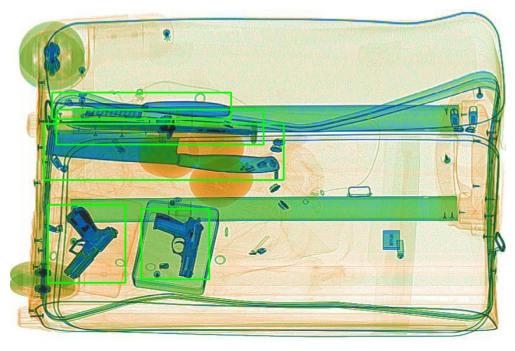

./data/labels/train\PID_xray_hidden04305.txt


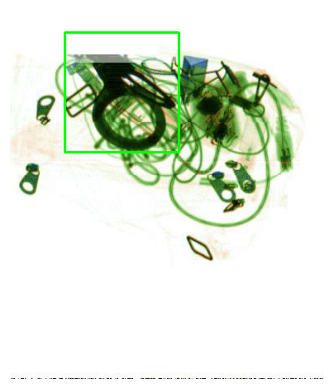

<Figure size 640x480 with 0 Axes>

In [41]:
images = "./data/images/train"
labels = "./data/labels/train"
N_SAMPLES = 5
random_sample = random.sample(os.listdir(images), N_SAMPLES)
plt.figure(figsize=(5, 5))

for sample in random_sample:
    img = os.path.join(images, sample)
    
    # We need CV2 to draw a bounding box over the images
    image = cv2.imread(img)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_h, img_w, _ = image.shape

    # Replace .jpg with .txt
    print(os.path.join(labels, sample.split('.')[0] + '.txt'))
    with open(os.path.join(labels, sample.split('.')[0] + '.txt'), 'r') as f:
        for line in f.readlines():
            _, x_c, y_c, w, h = [float(i) for i in line.split()] # First value is class, don't need 
            x1 = int((x_c - w / 2) * img_w)
            y1 = int((y_c - h / 2) * img_h)
            x2 = int((x_c + w / 2) * img_w)
            y2 = int((y_c + h / 2) * img_h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

plt.tight_layout()

plt.show()

##### It's important to note that some images may come with multiple flagged items 

#### Let's make sure the labels are not skewed (some labels are not overrepresented)

Counter({10: 1224, 2: 1222, 5: 1215, 9: 1209, 6: 1201, 0: 1200, 3: 1200, 1: 1198, 11: 1192, 4: 1191, 7: 1182, 8: 1179})


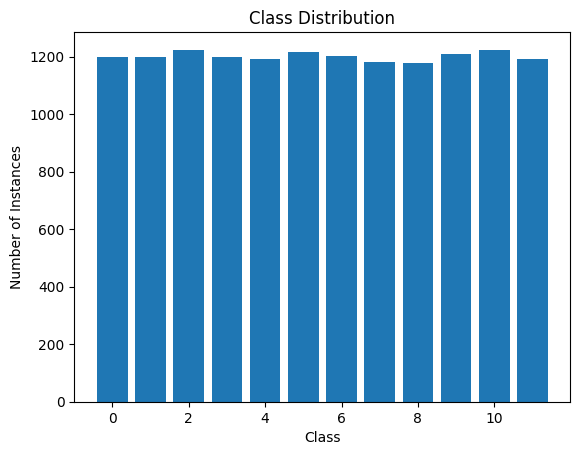

Max / Min ratio: 1.0381679389312977


In [39]:
# Count class occcurences
from collections import Counter

labels_path = "./data/labels/train"

class_counts = Counter()

for label_file in os.listdir(labels_path):
    with open(os.path.join(labels_path, label_file), 'r') as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

print(class_counts)

# Plot distribution

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure()
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.title("Class Distribution")
plt.show()

# Check imbalance ratio
max_count = max(class_counts.values())
min_count = min(class_counts.values())

print("Max / Min ratio:", max_count / min_count)

A MM ratio of 1.038 is extremely close to 1, so we should have no fear of overfitting

#### Training
We'll use YOLOv8 because that's the baseline. We can do experimenting with other models in the future, but for now we're just trying to get this to work!

In [ ]:
model = YOLO("yolov8s.pt") # s here can be replaced with n, which offers more speed at the cost of accuracy (I assume)

# I've already fixed the yaml paths to work relatively
yml = "./data/data.yaml"

results = model.train(data=yml, epochs=5, imgsz=640, batch=16, save=True)

Ultralytics 8.4.27  Python-3.11.4 torch-2.11.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

KeyboardInterrupt: 

: 